# Contextualização

Este projeto visa analisar as tendências e características de evasão e aprovação no curso técnico EAD de tecnologia, com foco específico na trilha técnica em Tecnologia da Informação. O itinerário formativo é composto por oito módulos: Projeto de Vida (PV), Empreendedorismo (EM), Inglês (EN), Lógica de Programação (LP), Módulo Técnico Básico (CD MB), Intermediário (CD MI), Avançado (CD MA) e Imersão.

Um ponto relevante da estrutura curricular é que as disciplinas de PV, EM, EN e LP contaram com processos de recuperação e ocorreram de forma concomitante, seguindo o cronograma: PV e EM (julho), EM e EN (agosto) e EN e LP (setembro).

Após uma etapa de limpeza e tratamento dos dados brutos, a análise foi estruturada em duas fases principais:

* Fase 1: Síntese de Performance e Tendências

* Fase 2: Detalhamento do Perfil e Cruzamento de Dados

# 1. Configuração e Carga dos Dados

In [ ]:
import pandas as pd
import numpy as np
import os

# Caminho para o arquivo
FILE_PATH = '/content/Dados_Pessoais_Anonimizados.xlsx'

def carregar_e_unir_dados(path):
    if not os.path.exists(path):
        print(f"ERRO: Arquivo não encontrado em {path}.")
        return None

    # Carga das abas
    sheets = {
        'pessoais': pd.read_excel(path, sheet_name='Dados_Pessoais'),
        'notas': pd.read_excel(path, sheet_name='NotasStatus'),
        'ids': pd.read_excel(path, sheet_name='ID_Ment_ID_Prof')
    }

    # Merge das tabelas pelo ID
    df = sheets['pessoais'].merge(sheets['notas'], on='ID', how='inner') \
                           .merge(sheets['ids'], on='ID', how='inner', suffixes=('', '_y'))

    # Limpeza de colunas duplicadas do merge
    df.drop(columns=[c for c in df.columns if c.endswith('_y')], inplace=True)

    # Filtro de Escopo: Apenas trilha técnica alvo
    df = df[df['CURSO MATRICULADO'].str.contains('Ciência de Dados', na=False, case=False)].copy()

    print(f"Dados carregados com sucesso! Total de alunos em CD: {len(df)}")
    return df

df_base = carregar_e_unir_dados(FILE_PATH)

Dados carregados com sucesso! Total de alunos em CD: 1545


1. Esta etapa compreende a extração e unificação de dados multitabulares. Através de operações de Join (Inner Merge), o algoritmo consolida as abas de dados cadastrais, performance acadêmica (notas) e identificadores de mentoria em um único DataFrame estruturado (df_base). O processo utiliza o ID do discente como chave primária, assegurando a integridade referencial entre as diferentes fontes de informação.

2. Para garantir a qualidade analítica, o código executa o saneamento automatizado de redundâncias, eliminando colunas duplicadas geradas na integração. Adicionalmente, aplica-se um filtro de granularidade para isolar exclusivamente o curso de Ciência de Dados.

# 2. Limpeza e Padronização (Data Cleaning)

In [ ]:
def limpar_dados(df):
    if df is None: return None

    # Tratamento de Nulos por Categoria
    mapeamento_nulos = {
        'Não Cursou': [c for c in df.columns if 'Turma' in c],
        'Não Realizado': ['Status CD MB', 'Status CD MI', 'Status CD MA', 'Status Imersão'],
        'Não': ['Suspenso PV', 'Suspenso REC', 'Suspenso EM', 'Suspenso REC EM',
                'Suspenso LP', 'Suspenso REC LP', 'Suspenso EN', 'Suspenso REC EN',
                'Suspenso CD MB', 'Suspenso CD MI', 'Suspenso CD MA',
                'Interesse em Voltar', 'Certificado Imersão', 'Certificação Finalizada', 'DESISTENTE FORMAL'],
        'Não Desistente': ['MOTIVO DESISTÊNCIA']
    }

    for valor, colunas in mapeamento_nulos.items():
        cols_existentes = [c for c in colunas if c in df.columns]
        df[cols_existentes] = df[cols_existentes].fillna(valor)

    # Tratamento de Idade
    df['IDADE_INSCRICAO'] = pd.to_numeric(df['IDADE_INSCRICAO'], errors='coerce')
    df.loc[(df['IDADE_INSCRICAO'] < 14) | (df['IDADE_INSCRICAO'] > 90), 'IDADE_INSCRICAO'] = np.nan
    df['IDADE_INSCRICAO'] = df['IDADE_INSCRICAO'].fillna(df['IDADE_INSCRICAO'].median())

    # Padronização de Colunas Geográficas e Desistência
    if 'CAPITAL OU RMF' in df.columns:
        df.rename(columns={'CAPITAL OU RMF': 'RMF OU INTERIOR'}, inplace=True)

    df.loc[(df['MOTIVO DESISTÊNCIA'] != 'Não Desistente') & (df['DESISTENTE FORMAL'] == 'Não'), 'DESISTENTE FORMAL'] = 'Sim'

    # Criando a Situacao Final (Concluinte vs Desistente)
    df['SITUACAO_FINAL'] = df['Status Imersão'].apply(
        lambda x: 'Concluinte' if 'Aprovado' in str(x) or 'Ciclo II' in str(x) else 'Desistente'
    )

    print("Limpeza concluída com sucesso!")
    return df

df_final = limpar_dados(df_base)

Limpeza concluída com sucesso!


3. Esta etapa compreende o saneamento da base através da imputação semântica de valores ausentes. Substituímos campos nulos por termos contextuais (como "Não Cursou"), garantindo que o volume de dados fosse preservado sem a introdução de vieses estatísticos. Um exemplo crítico foi o tratamento das variáveis de suspensão (ex: Suspenso PV): a análise identificou uma lógica binária onde apenas os casos positivos estavam registrados; dessa forma, a ausência de valor foi convertida em "Não". No caso específico da coluna Suspenso REC EM, que se encontrava integralmente vazia, a decisão de imputação foi validada junto à Supervisão do Projeto, confirmando que nenhum aluno havia sido suspenso naquela etapa. Isso assegurou a fidedignidade dos dados transformados.

4. O algoritmo executa o tratamento da variável de Idade, identificando e corrigindo outliers (valores atípicos ou erros de digitação). Optou-se pela imputação pela mediana para preencher lacunas e inconsistências, mantendo o equilíbrio estatístico e evitando que valores extremos distorcessem a média do público-alvo. Paralelamente, realizou-se a normalização das colunas de localidade, para garantir que as análises fossem precisas.

5. Foi desenvolvida a métrica SITUACAO_FINAL, uma variável derivada que consolida o status de "Desistência Formal" com o desempenho no módulo de "Imersão". Através desta lógica, classificamos cada estudante de forma binária como Concluinte ou Desistente.

# 3. Métricas

In [ ]:
def calcular_fluxo_aprovacao(df):
    metricas = []
    total_cd = len(df)

    # Função interna para contar aprovados garantindo que o status seja string
    def count_aprov_filtered(dataframe, disc):
        return len(dataframe[dataframe[f'Status {disc}'].astype(str).str.contains('Aprovado|Média 5|Ciclo II', na=False)])

    # 1. Disciplinas Iniciais (Base total 1545)
    for disc in ['PV', 'EM', 'EN']:
        metricas.append({
            'Fase': 'Inicial',
            'Disciplina': disc,
            'Aprovados': count_aprov_filtered(df, disc),
            'Base': total_cd
        })

    # 2. Lógica de LP (REVISADA)
    mask_apto_lp = (df['Status PV'].astype(str).str.contains('Aprovado', na=False)) & \
                   (df['Status EM'].astype(str).str.contains('Aprovado', na=False))
    df_lp = df[mask_apto_lp]

    base_lp = len(df_lp)
    aprov_lp = count_aprov_filtered(df_lp, 'LP')

    metricas.append({
        'Fase': 'Técnica',
        'Disciplina': 'LP',
        'Aprovados': aprov_lp,
        'Base': base_lp
    })

    # 3. Ciclo de Especialização (Baseado no sucesso de LP)
    base_especializacao = aprov_lp

    for mod in ['CD MB', 'CD MI', 'CD MA', 'Imersão']:
        aprov_mod = count_aprov_filtered(df, mod)
        base_segura = max(base_especializacao, aprov_mod)

        metricas.append({
            'Fase': 'Especialização',
            'Disciplina': mod,
            'Aprovados': aprov_mod,
            'Base': base_segura
        })
        base_especializacao = aprov_mod

    res = pd.DataFrame(metricas)
    res['Taxa_Sucesso %'] = (res['Aprovados'] / res['Base'] * 100).round(2)
    return res

def calcular_eficacia_rec(df):
    recs = ['PV', 'EM', 'LP', 'EN']
    res_rec = []
    for r in recs:
        alunos_rec = df[df[f'Turma REC {r}'] != 'Não Cursou']
        total = len(alunos_rec)
        resgatados = len(alunos_rec[alunos_rec[f'Status {r}'].astype(str).str.contains('Aprovado', na=False)])
        res_rec.append({
            'Disciplina': r, 'Em REC': total, 'Resgatados': resgatados,
            'Eficácia %': round((resgatados/total*100), 2) if total > 0 else 0
        })
    return pd.DataFrame(res_rec)

6. Esta etapa transforma os dados brutos em indicadores de performance, estruturando um Funil de Sucesso. A lógica aplica um "efeito cascata": a base de cálculo de cada módulo técnico é composta apenas pelos aprovados na etapa anterior, permitindo identificar com precisão onde ocorrem os maiores gargalos de retenção.

7. O algoritmo isola especificamente os alunos que utilizaram as aulas de recuperação (PV, EM, LP e EN) para calcular a Taxa de Resgate. Este indicador de impacto valida a efetividade do esforço pedagógico extra, medindo quantos estudantes converteram uma REC em aprovação final.

# 4. Sumário de Resultados

In [ ]:
if df_final is not None:
    # Aptidão Técnica
    mask_apto_lp = (df_final['Status PV'].str.contains('Aprovado', na=False)) & \
                   (df_final['Status EM'].str.contains('Aprovado', na=False))
    base_lp = len(df_final[mask_apto_lp])

    # Conclusão Total (8/8)
    status_cols = [f'Status {d}' for d in ['PV', 'EM', 'LP', 'EN', 'CD MB', 'CD MI', 'CD MA', 'Imersão']]
    concluintes_8 = df_final[df_final[status_cols].apply(lambda r: all('Aprovado' in str(v) for v in r), axis=1)]

    print("="*50)
    print("      RELATÓRIO DE DESEMPENHO - TRILHA TÉCNICA")
    print("="*50)
    print(f"Público Total Analisado: {len(df_final)} alunos")
    print(f"Alunos aptos para o módulo de LP: {base_lp}")
    print(f"Concluintes Integrais (8/8 módulos): {len(concluintes_8)}")
    print("-" * 50)

    print("\nTABELA 1: FLUXO DE SOBREVIVÊNCIA ACADÊMICA")
    print(calcular_fluxo_aprovacao(df_final).to_string(index=False))

    print("\nTABELA 2: IMPACTO DA RECUPERAÇÃO (REC)")
    print(calcular_eficacia_rec(df_final).to_string(index=False))
    print("="*50)

      RELATÓRIO DE DESEMPENHO - CIÊNCIA DE DADOS
Público Total Analisado: 1545 alunos
Alunos aptos para o módulo de LP: 561
Concluintes Integrais (8/8 módulos): 207
--------------------------------------------------

TABELA 1: FLUXO DE SOBREVIVÊNCIA ACADÊMICA
          Fase Disciplina  Aprovados  Base  Taxa_Sucesso %
       Inicial         PV        688  1545           44.53
       Inicial         EM        587  1545           37.99
       Inicial         EN        541  1545           35.02
       Técnica         LP        480   561           85.56
Especialização      CD MB        438   480           91.25
Especialização      CD MI        354   438           80.82
Especialização      CD MA        318   354           89.83
Especialização    Imersão        243   318           76.42

TABELA 2: IMPACTO DA RECUPERAÇÃO (REC)
Disciplina  Em REC  Resgatados  Eficácia %
        PV     315          31        9.84
        EM      19          13       68.42
        LP     174          14        8.

In [ ]:
# INTEGRIDADE DA BASE
print(f"Volume Total de Alunos: {len(df_final)}")
print("-" * 30)

# Confere se a soma de Concluintes e Desistentes bate com o total
concluintes = len(df_final[df_final['SITUACAO_FINAL'] == 'Concluinte'])
desistentes = len(df_final[df_final['SITUACAO_FINAL'] == 'Desistente'])
soma_total = concluintes + desistentes

print(f"Concluintes: {concluintes}")
print(f"Desistentes: {desistentes}")
print(f"Soma Validada: {soma_total}")

if soma_total == len(df_final):
    print("Todos os alunos estão classificados corretamente!")
else:
    print("Há uma diferença de", len(df_final) - soma_total, "alunos sem classificação!")

Volume Total de Alunos: 1545
------------------------------
Concluintes: 243
Desistentes: 1302
Soma Validada: 1545
Todos os alunos estão classificados corretamente!


# Análise Gráfica

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import subprocess
import sys

def garantir_dependencias():
    for lib in ['matplotlib-venn', 'venn']:
        try:
            __import__(lib.replace('-', '_'))
        except ImportError:
            subprocess.check_call([sys.executable, "-m", "pip", "install", lib, "--quiet"])

garantir_dependencias()
from matplotlib_venn import venn2
from venn import venn

# Configurações Globais de Visualização
%matplotlib inline
sns.set_theme(style="white")
plt.rcParams.update({'figure.figsize': (12, 8), 'font.size': 12, 'axes.spines.top': False, 'axes.spines.right': False})
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
termos_sucesso = ['Aprovado', 'Ciclo II', 'Média 5', 'Concluído']

# Fase 1: Síntese de Performance e Tendências

Nesta etapa, os dados foram sintetizados para identificar padrões ao longo de todo o ciclo. O objetivo é mapear o percentual de alunos que mantiveram a assiduidade, especialmente nos módulos técnicos finais, além de identificar quais disciplinas apresentaram as maiores e menores taxas de retenção. Para isso, foram geradas tabelas finais de resultados (aprovados vs. evadidos) por módulo e traçado o perfil dos alunos desistentes, correlacionando o momento da evasão com as disciplinas cursadas para discutir possíveis causas.

In [ ]:
def exibir_fase1_resgate_academico(df):
    """Analisa o impacto das recuperações no sucesso final."""
    recs, res = ['PV', 'EM', 'LP', 'EN'], []
    for r in recs:
        # Filtra apenas quem de fato precisou e cursou a REC
        df_r = df[df[f'Turma REC {r}'].astype(str) != 'Não Cursou']
        aprov = len(df_r[df_r[f'Status {r}'].astype(str).str.contains('Aprovado|Média 5|Ciclo II', na=False)])
        res.append({'Disc': r, 'Total': len(df_r), 'Aprov': aprov, 'Desist': len(df_r)-aprov})

    df_res = pd.DataFrame(res)

    # Criando perfil para comparação
    df['Perfil'] = np.where(df[[f'Turma REC {r}' for r in recs]].astype(str).apply(lambda x: x != 'Não Cursou').any(axis=1), 'Fez REC', 'Passou Direto')

    t_abs = pd.crosstab(df['Perfil'], df['SITUACAO_FINAL'])
    t_rel = pd.crosstab(df['Perfil'], df['SITUACAO_FINAL'], normalize='index') * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # Gráfico 1: Perfil Geral
    t_rel.plot(kind='bar', stacked=True, ax=ax1, color=['#2ca02c', '#d62728'], edgecolor='black', rot=0)
    ax1.set_title('Desfecho por Perfil de Aluno', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Porcentagem (%)', fontsize=12)
    ax1.set_xlabel('Grupo de Estudantes', fontsize=12)

    for i in range(len(t_rel)):
        ax1.text(i, 102, f'Concluintes: {t_rel.iloc[i, 0]:.1f}%\nDesistentes: {t_rel.iloc[i, 1]:.1f}%',
                 ha='center', va='bottom', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))

    # Gráfico 2: Eficácia da REC
    ax2.bar(df_res['Disc'], df_res['Aprov'], label='Resgatados (Sucesso)', color='#2ca02c', edgecolor='black')
    ax2.bar(df_res['Disc'], df_res['Desist'], bottom=df_res['Aprov'], label='Não Resgatados (Evasão)', color='#d62728', edgecolor='black')
    ax2.set_title('Eficácia do Resgate em Recuperação (REC)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Quantidade de Alunos', fontsize=12)
    ax2.set_xlabel('Disciplinas com REC', fontsize=12)

    for i, r in df_res.iterrows():
        ax2.text(i, r['Total'] + 1, f"Sucesso: {int(r['Aprov'])}\nEvasão: {int(r['Desist'])}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax1.set_ylim(0, 130); ax2.set_ylim(0, df_res['Total'].max()*1.4)
    ax1.legend(['Concluinte', 'Desistente'], loc='upper right')
    ax2.legend()
    sns.despine(); plt.tight_layout(); plt.show()

def exibir_fase1_tendencia_desgaste(df):
    """Gráfico de dispersão mostrando a queda de eficiência ao longo do tempo."""
    df_plot = calcular_fluxo_aprovacao(df).rename(columns={'Aprovados': 'n', 'Taxa_Sucesso %': 'Efic'})

    plt.figure(figsize=(15, 8))
    plt.axhspan(0, 50, color='red', alpha=0.15, label='Zona Crítica de Evasão')
    plt.plot(df_plot['Disciplina'], df_plot['Efic'], color='silver', linestyle='--', alpha=0.5)

    sns.scatterplot(data=df_plot, x='Disciplina', y='Efic', size='n', sizes=(300, 1800),
                    hue='Efic', palette='RdYlGn', legend=False)

    for i, row in df_plot.iterrows():
        plt.text(i, row['Efic'] + 5, f"{row['Efic']:.1f}%", ha='center', fontweight='bold', fontsize=11)

    plt.title('Tendência de Desgaste: Taxa de Sucesso por Etapa', fontsize=15, fontweight='bold')
    plt.ylabel('Taxa de Aprovação (%)', fontsize=12)
    plt.xlabel('Módulos do Curso (Ordem Cronológica)', fontsize=12)
    plt.ylim(0, 115)
    sns.despine()
    plt.show()

def exibir_fase1_performance_modular_barras(df):
    """Barras comparativas de Sucesso vs Evasão por módulo."""
    m = calcular_fluxo_aprovacao(df)
    m['Evasao'] = m['Base'] - m['Aprovados']

    ax = m.plot(x='Disciplina', y=['Aprovados', 'Evasao'], kind='bar',
                color=['#2ca02c', '#d62728'], figsize=(14, 7), width=0.8, edgecolor='black')

    for i, p in enumerate(ax.patches):
        val = p.get_height()
        base = m['Base'].iloc[i % len(m)]
        perc = (val / base * 100) if base > 0 else 0
        ax.annotate(f'n={int(val)}\n({perc:.1f}%)', (p.get_x() + p.get_width()/2, val),
                    ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5), textcoords="offset points")

    plt.title('Performance Modular: Alunos Aprovados vs. Desistentes', fontsize=15, fontweight='bold', pad=25)
    plt.ylabel('Quantidade de Estudantes', fontsize=12)
    plt.xlabel('Disciplinas/Módulos', fontsize=12)
    plt.legend(['Aprovados (Sucesso)', 'Evadidos (Desistência)'])
    plt.ylim(0, m['Base'].max() * 1.3)
    plt.xticks(rotation=0)
    sns.despine()
    plt.show()

def exibir_fase1_causa_raiz_pareto(df):
    """Gráfico de Pareto para identificar os principais motivos de desistência."""
    # Filtra apenas quem desistiu
    dados_evasao = df[df['MOTIVO DESISTÊNCIA'] != 'Não Desistente']
    df_mot = dados_evasao['MOTIVO DESISTÊNCIA'].value_counts().reset_index()
    df_mot.columns = ['Motivo', 'Qtd']
    df_mot['Acumulado'] = (df_mot['Qtd'].cumsum() / df_mot['Qtd'].sum()) * 100

    fig, ax1 = plt.subplots(figsize=(14, 8))
    sns.barplot(x='Motivo', y='Qtd', data=df_mot, palette='flare', ax=ax1, edgecolor='black')

    ax1.set_xticklabels([m[:25] + '...' if len(m) > 25 else m for m in df_mot['Motivo']], rotation=40, ha='right')

    ax2 = ax1.twinx()
    ax2.plot(df_mot['Motivo'], df_mot['Acumulado'], color='#d62728', marker='D', linewidth=2, label='% Acumulada')
    ax2.axhline(80, color='blue', linestyle='--', label='Corte 80% (Pareto)')

    ax1.set_title('Análise de Causa Raiz: Por que os alunos desistem?', fontsize=15, fontweight='bold')
    ax1.set_ylabel('Frequência (Quantidade de Alunos)', fontsize=12)
    ax2.set_ylabel('Porcentagem Acumulada (%)', fontsize=12)
    ax1.set_xlabel('Principais Motivos Relatados', fontsize=12)

    plt.tight_layout()
    plt.show()

def exibir_fase1_taxa_sucesso_simples(df):
    """Restauração: Gráfico de barras das taxas isoladas por disciplina"""
    df_fluxo = calcular_fluxo_aprovacao(df)

    plt.figure(figsize=(14, 7))
    ax = sns.barplot(x='Disciplina', y='Taxa_Sucesso %', data=df_fluxo,
                     palette='viridis', edgecolor='black')

    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10,
                    fontweight='bold', xytext=(0, 5),
                    textcoords='offset points')

    plt.title('Taxa de Sucesso por Disciplina (Retenção Isolada)', fontsize=15, fontweight='bold')
    plt.ylabel('Taxa de Aprovação (%)')
    plt.xlabel('Disciplinas')
    plt.ylim(0, 110)
    sns.despine()
    plt.show()

def exibir_fase1_funil_conversao_plotly(df):
    """Gera o Funil de Conversão com bases independentes para o ciclo inicial"""
    import plotly.graph_objects as go

    etapas = ['PV', 'EM', 'EN', 'LP', 'CD MB', 'CD MI', 'CD MA', 'Imersão']
    aprovados = [688, 587, 541, 480, 438, 354, 318, 243]

    bases = [1545, 1545, 1545, 561, 480, 438, 354, 318]

    textos = [f"n={a}<br>({(a/b*100):.2f}% da Base)" for a, b in zip(aprovados, bases)]

    fig = go.Figure(go.Funnel(
        y = etapas,
        x = aprovados,
        text = textos,
        textinfo = "text",
        hoverinfo = "y+text",
        marker = {"color": ["#1f77b4", "#1f77b4", "#1f77b4", "#ff7f0e", "#2ca02c", "#2ca02c", "#2ca02c", "#d62728"]},
        connector = {"line": {"color": "gray", "width": 2}}
    ))

    fig.update_layout(
        title={
            'text': "Funil de Sobrevivência",
            'x': 0.5,
            'font': {'size': 20}
        },
        height=700,
        yaxis={'title': 'Disciplinas/Módulos'}
    )

    fig.show()

def exibir_fase1_funil_concomitancia(df):
    """Plota a concomitância mensal em 3 diagramas de Venn lado a lado"""
    from matplotlib_venn import venn2

    def get_aprovados(disc):
        return set(df[df[f'Status {disc}'].astype(str).str.contains('Aprovado|Média 5|Ciclo II', na=False)].index)

    # Conjuntos de aprovados
    pv, em, en, lp = get_aprovados('PV'), get_aprovados('EM'), get_aprovados('EN'), get_aprovados('LP')

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))

    # Julho: PV e EM
    venn2([pv, em], ('PV (Julho)', 'EM (Julho)'), ax=ax1, set_colors=('#1f77b4', '#ff7f0e'))
    ax1.set_title("Concomitância: Julho", fontsize=14, fontweight='bold')

    # Agosto: EM e EN
    venn2([em, en], ('EM (Agosto)', 'EN (Agosto)'), ax=ax2, set_colors=('#ff7f0e', '#2ca02c'))
    ax2.set_title("Concomitância: Agosto", fontsize=14, fontweight='bold')

    # Setembro: EN e LP
    venn2([en, lp], ('EN (Setembro)', 'LP (Setembro)'), ax=ax3, set_colors=('#2ca02c', '#d62728'))
    ax3.set_title("Concomitância: Setembro", fontsize=14, fontweight='bold')

    plt.suptitle("Evolução da Sincronia Acadêmica por Mês de Execução", fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()


from venn import venn

def exibir_fase1_sincronia_venn(df):
    """Gera o Diagrama de Venn de 4 conjuntos com elipses para PV, EM, EN e LP"""

    def get_indices(disc):
        return set(df[df[f'Status {disc}'].astype(str).str.contains('Aprovado|Média 5|Ciclo II', na=False)].index)

    conjuntos = {
        "PV": get_indices('PV'),
        "EM": get_indices('EM'),
        "EN": get_indices('EN'),
        "LP": get_indices('LP')
    }

    plt.figure(figsize=(12, 12))

    venn(conjuntos,
         fmt="{size}",
         fontsize=10,
         legend_loc="upper left",
         cmap="viridis")

    plt.title("Interseção das 4 Disciplinas Iniciais\n(Cruzamento de Aprovações PV, EM, EN e LP)",
              fontsize=16, fontweight='bold', pad=30)

    plt.show()

def exibir_fase1_matriz_interdependencia(df):
    """Gera uma matriz de calor mostrando a probabilidade de sucesso entre módulos."""
    import seaborn as sns
    import matplotlib.pyplot as plt

    colunas = ['Status PV', 'Status EM', 'Status EN', 'Status LP',
               'Status CD MB', 'Status CD MI', 'Status CD MA']
    nomes_curtos = ['PV', 'EM', 'EN', 'LP', 'CD MB', 'CD MI', 'CD MA']

    df_bin = pd.DataFrame()
    for col, nome in zip(colunas, nomes_curtos):
        df_bin[nome] = df[col].astype(str).str.contains('Aprovado|Média 5|Ciclo II', na=False).astype(int)

    matriz = pd.DataFrame(index=nomes_curtos, columns=nomes_curtos)

    for i in nomes_curtos:
        for j in nomes_curtos:
            base_alunos = df_bin[df_bin[i] == 1]
            if len(base_alunos) > 0:
                probabilidade = (base_alunos[j].sum() / len(base_alunos)) * 100
                matriz.loc[i, j] = probabilidade
            else:
                matriz.loc[i, j] = 0

    matriz = matriz.astype(float)

    plt.figure(figsize=(12, 9))

    sns.heatmap(matriz,
                annot=True,
                fmt=".1f",
                cmap="YlGnBu",
                cbar_kws={'label': 'Probabilidade de Sucesso (%)'},
                linewidths=.5,
                annot_kws={"size": 10, "weight": "bold"})

    plt.title('Matriz de Interdependência Acadêmica',
              fontsize=15, fontweight='bold', pad=20)
    plt.ylabel('Módulo de Origem (Se aprovado em...)', fontsize=12)
    plt.xlabel('Módulo de Destino (Probabilidade de aprovar em...)', fontsize=12)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_747/1267340915.py:121: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




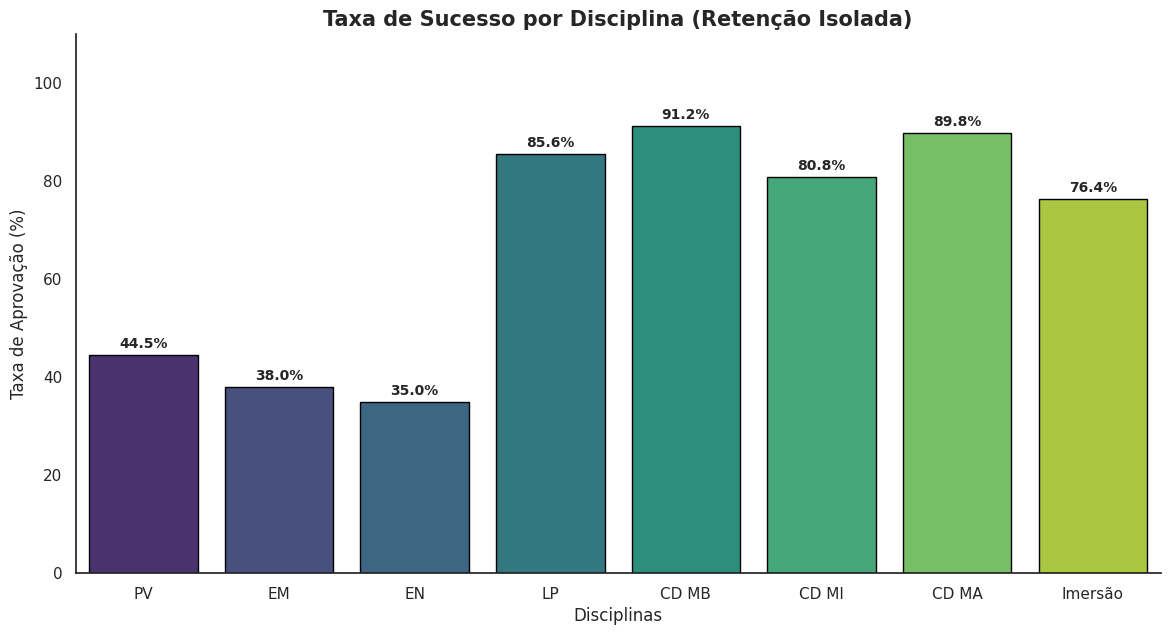

In [ ]:
exibir_fase1_taxa_sucesso_simples(df_final)

#Análise da Taxa de Sucesso por Disciplina (Retenção Isolada)

Neste gráfico, apresentamos a Taxa de Sucesso Simples por componente curricular, o que representa a eficácia de aprovação em cada disciplina analisada de forma isolada.

#Observações Principais:

* Gargalo Inicial: É possível notar que as três primeiras disciplinas (PV, EM e EN) apresentam as menores taxas de sucesso do programa. Esse fenômeno indica um "filtro natural" no início da jornada, onde o nível de exigência acadêmica impacta diretamente o volume de concluintes.

* Estabilização: Em contraste, as cinco disciplinas finais apresentam uma taxa de aprovação substancialmente maior.

* Conclusão de Fluxo: Essa elevação na performance sugere que os alunos que superam os módulos iniciais possuem maior resiliência e maturidade técnica, resultando em um aproveitamento quase integral nas etapas de especialização e imersão.

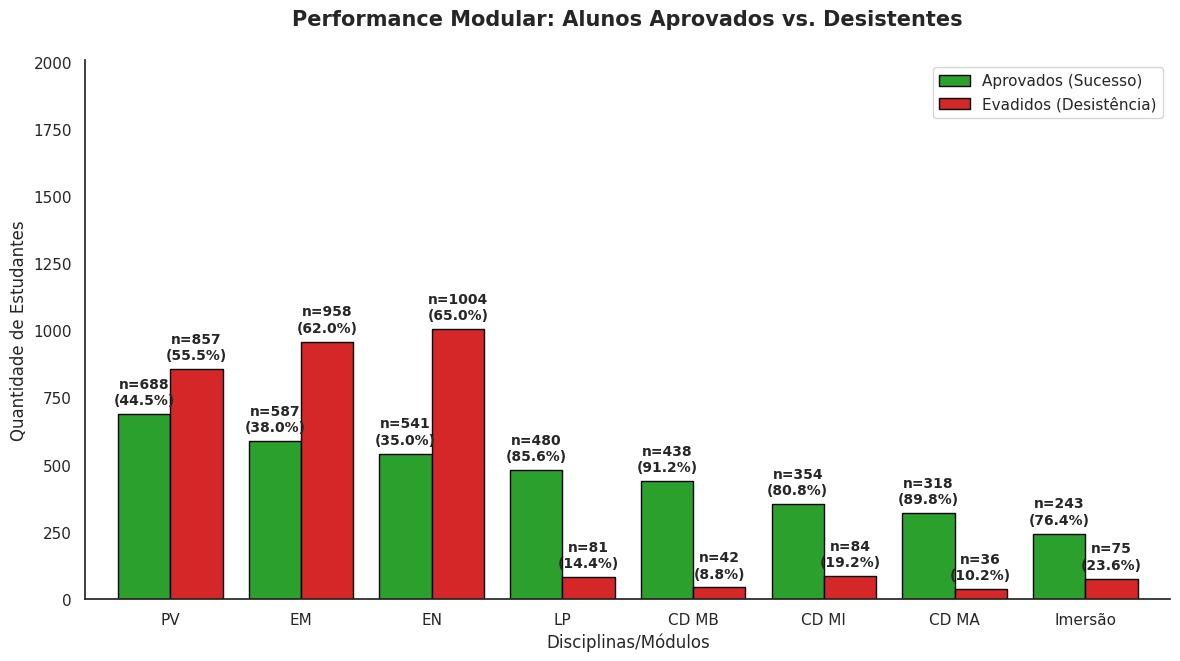

In [ ]:
exibir_fase1_performance_modular_barras(df_final)

#Análise de Performance Modular

Este gráfico oferece uma visão detalhada e comparativa da performance acadêmica, apresentando simultaneamente os volumes absolutos ($n$) e as taxas percentuais de Aprovação (Sucesso) e Desistência (Evasão) para cada módulo.

#Observações Principais:

* Impacto de Volume Inicial: Embora as três disciplinas iniciais apresentem as menores taxas de aprovação, elas detêm as maiores colunas no gráfico. Isso ocorre porque o eixo Y representa a quantidade bruta de alunos. Como esses módulos recebem o contingente total de ingressantes ($1545$ registros), o impacto numérico da evasão é visualmente mais acentuado nestas etapas.

* Padrão de Funil Acadêmico: Observa-se um padrão claro de filtragem. Nos primeiros módulos, a taxa de reprovação é significativamente mais elevada. À medida que avançamos para as cinco disciplinas finais (ciclo de especialização), notamos uma inversão: as taxas de aprovação tornam-se majoritárias e os índices de evasão tornam-se residuais.

* Estabilidade na Especialização: A redução na altura das colunas nos módulos finais reflete o afunilamento natural do curso. Contudo, a eficiência acadêmica nestas etapas é superior, sugerindo que o grupo remanescente possui o perfil técnico e a maturidade necessários para a conclusão do projeto.

In [ ]:
exibir_fase1_funil_conversao_plotly(df_final)

#Funil de Conversão e Sobrevivência Acadêmica

Este gráfico de funil ilustra a jornada do discente ao longo do itinerário formativo, mapeando a retenção desde o ingresso até o módulo final de Imersão. A visualização permite identificar o "filtro natural" do curso.

1. Ciclo Inicial e Concomitância (PV, EM, EN)

Diferente de um funil tradicional, as três disciplinas iniciais (Projeto de Vida, Empreendedorismo e Inglês) compartilham a mesma Base de Ingressantes ($1545$ alunos). Isso ocorre porque esses módulos foram ministrados de forma concomitante. Portanto, a taxa de sucesso nestas etapas reflete a aprovação isolada sobre o total de matriculados, e não uma redução progressiva de um módulo para o outro.

2. O Ponto de Inflexão: Lógica de Programação (LP)

O módulo de LP representa um marco no funil técnico. Embora tenha ocorrido em paralelo com Inglês (EN), sua base de cálculo é de $561$ alunos.

* Critério de Aptidão: Esta base é composta exclusivamente por estudantes que obtiveram aprovação simultânea em PV e EM.

3. Ciclo de Especialização (Efeito Cascata)

A partir de Ciência de Dados (MB), o funil passa a operar em uma lógica de dependência direta (sequencial). A base de cada novo módulo é o número de aprovados na disciplina imediatamente anterior.

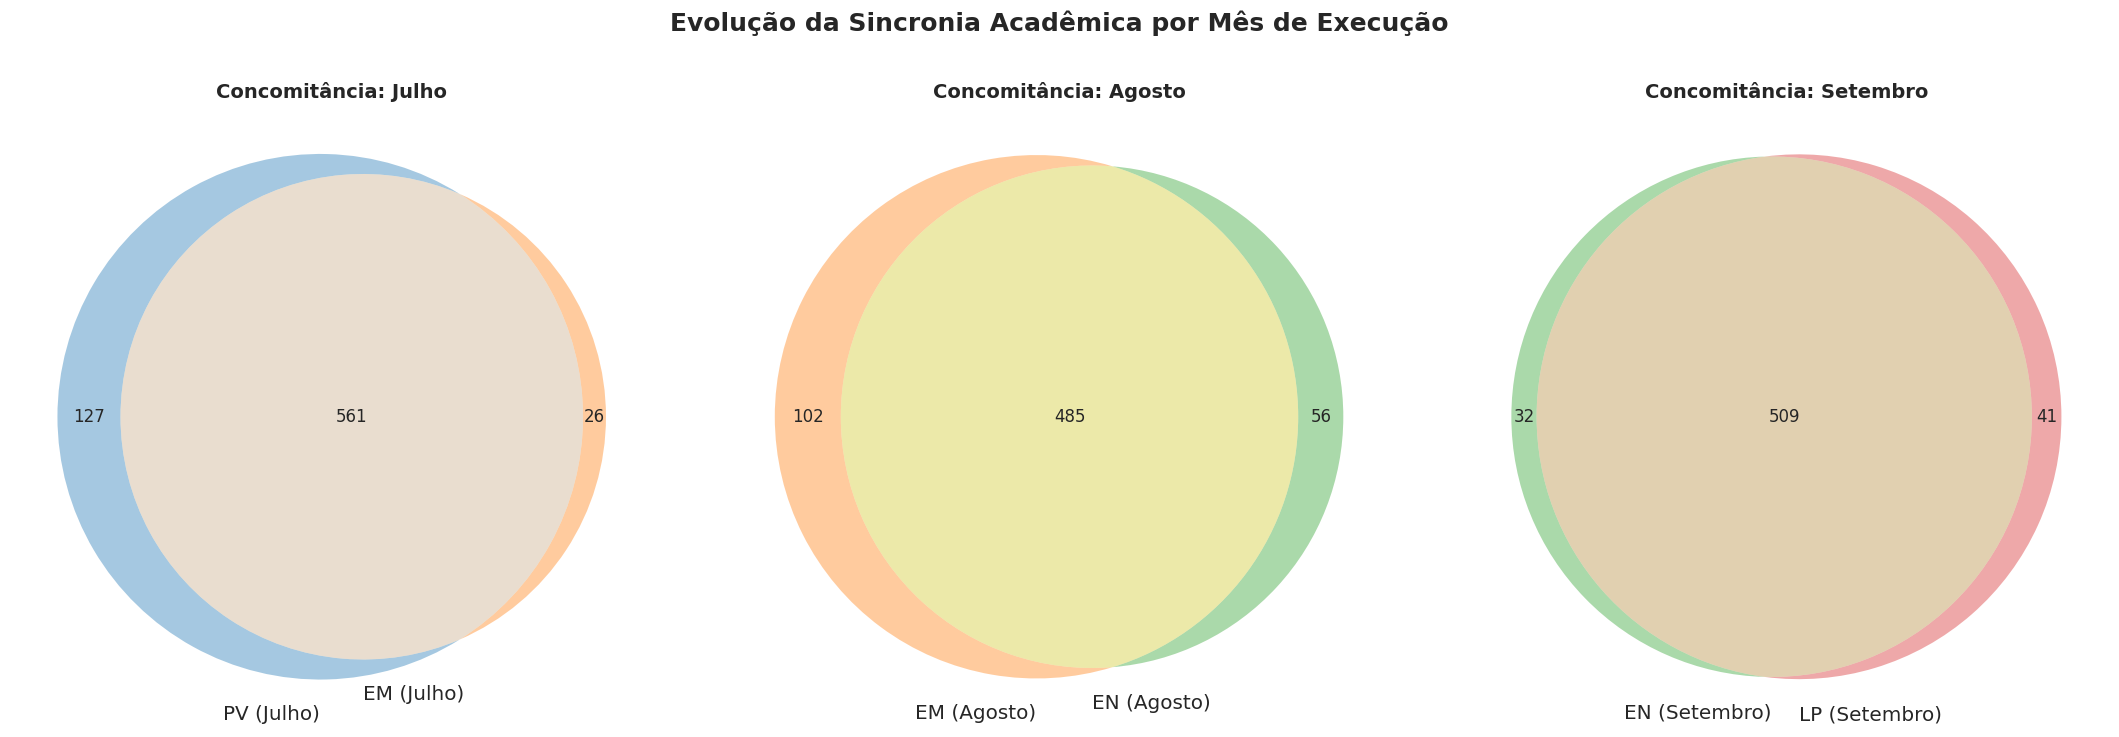

In [ ]:
exibir_fase1_funil_concomitancia(df_final)

<Figure size 1200x1200 with 0 Axes>

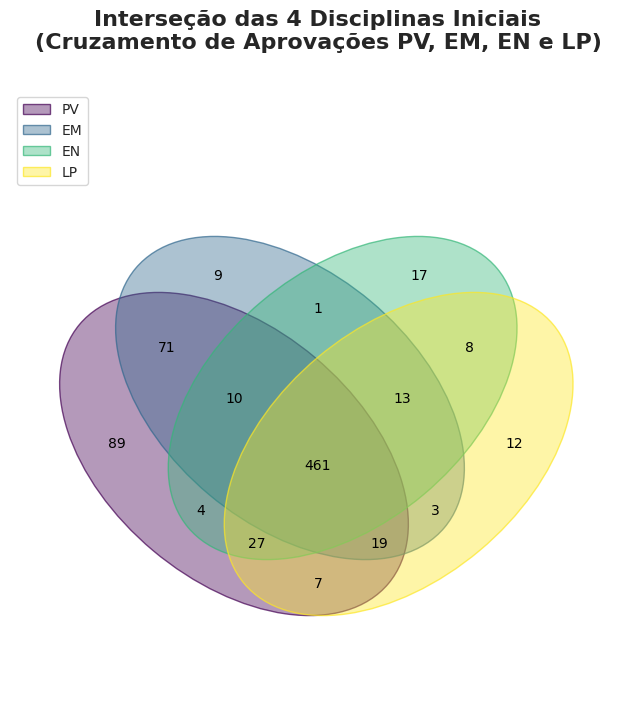

In [ ]:
exibir_fase1_sincronia_venn(df_final)

#Sincronia e Concomitância Acadêmica (Diagramas de Venn)

Os diagramas de Venn apresentados permitem visualizar, as intersecções e o paralelismo das disciplinas iniciais do itinerário formativo. Diferente de um fluxo linear, esta análise revela como os estudantes lidaram com a carga acadêmica simultânea em três momentos distintos:

* Julho (PV ∩ EM): Demonstra a capacidade de conciliação entre o desenvolvimento de competências socioemocionais e fundamentos de empreendedorismo.

* Agosto (EM ∩ EN): Mapeia a persistência dos alunos na transição para o aprendizado de língua estrangeira enquanto finalizavam o ciclo de empreendedorismo.

* Setembro (EN ∩ LP): Identifica o ponto de convergência, onde a lógica de programação (LP) foi feito simultaneamente ao Inglês.

#Intersecção Quadrangular

O diagrama de Intersecção Total (PV, EM, EN e LP) oferece um panorama geral da resiliência acadêmica. Ele estratifica o corpo discente em perfis distintos:

* Aprovação Integral: Estudantes que obtiveram sucesso em todas as disciplinas concomitantes (o centro das elipses).

* Desempenho Parcial: Alunos que progrediram em apenas algumas frentes.

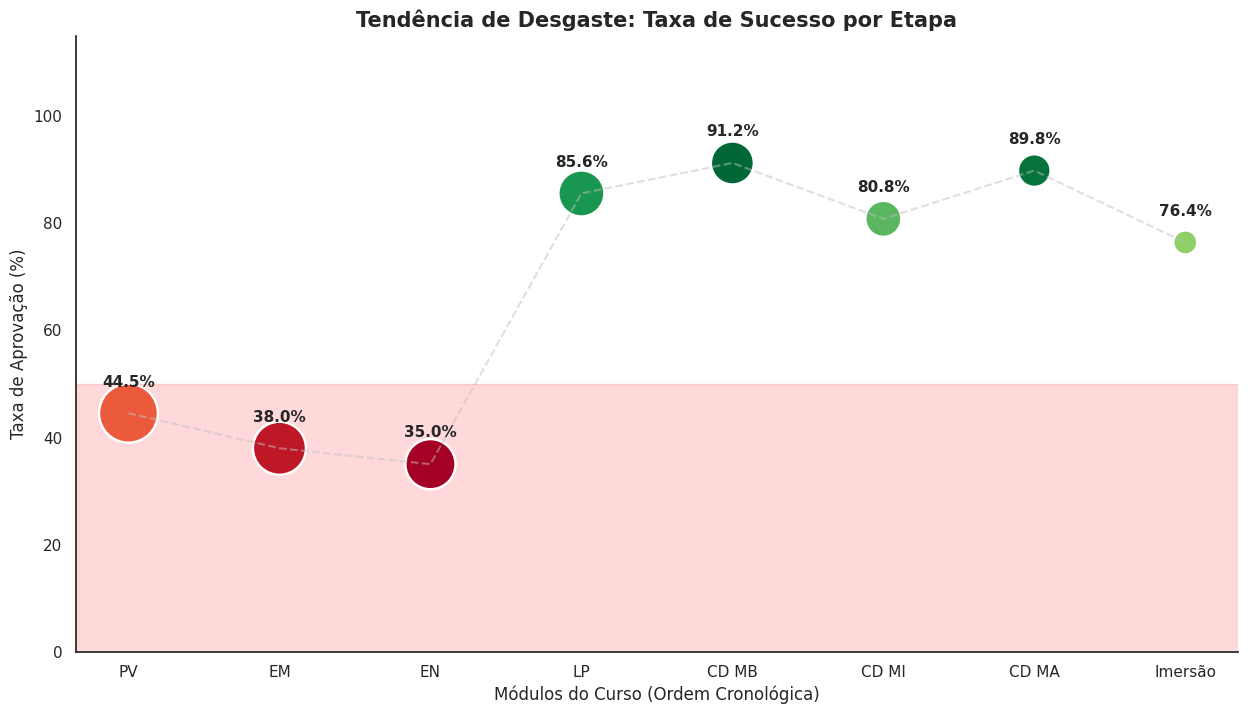

In [ ]:
exibir_fase1_tendencia_desgaste(df_final)

#Análise de Tendência de Desgaste e Zona Crítica de Retenção

Este gráfico mapeia a evolução da performance acadêmica ao longo do itinerário formativo, permitindo identificar os pontos de maior fragilidade na retenção de alunos.

#Observações Principais:

* Zona Crítica (Threshold de 50%):

Foi estabelecida uma linha de corte em $50\%$ (área sombreada em vermelho) para designar a zona crítica de evasão. Pontos situados abaixo desta marca representam módulos onde a perda de alunos supera o volume de aprovações, indicando um desgaste no fluxo acadêmico.

* Gargalo nos Módulos Iniciais:

Observa-se que a maior tendência de desgaste ocorre justamente no ciclo inicial (PV, EM e EN). Nestas etapas, a taxa de sucesso é sistematicamente inferior a $50\%$, sugerindo que o impacto da adaptação ao curso e a carga horária concomitante são os principais fatores de desmotivação ou reprovação.

* Recuperação de Performance:

Após superada a barreira dos módulos iniciais, a tendência de desgaste é revertida. Os módulos subsequentes (Ciclo Técnico e Especialização) operam com segurança acima da zona crítica, demonstrando que o grupo que permanece no curso possui um índice de maturidade acadêmica elevado.

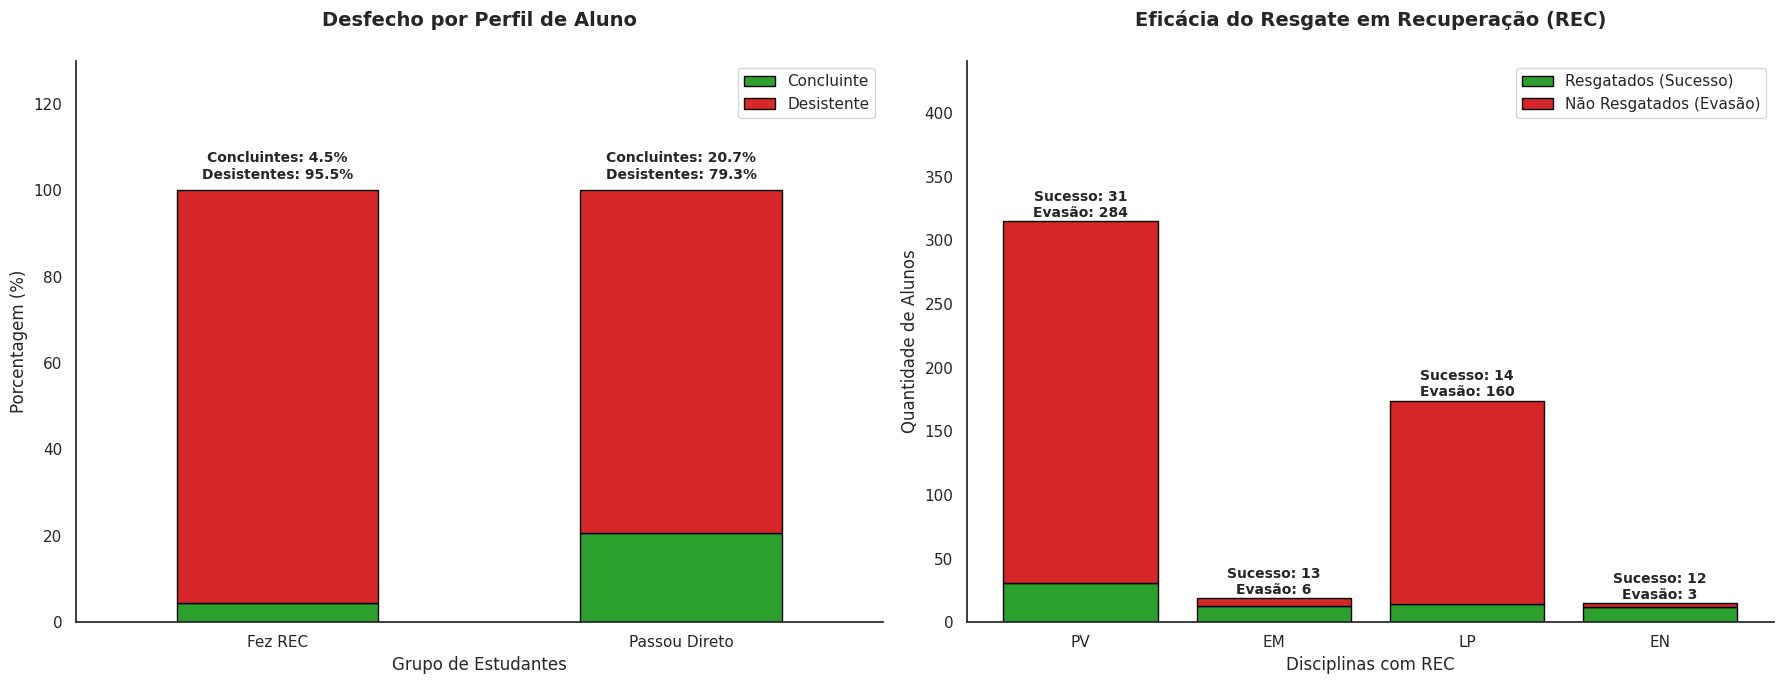

In [ ]:
exibir_fase1_resgate_academico(df_base)

#Eficácia do Resgate Acadêmico e Impacto da Recuperação (REC)

Esta análise bidimensional permite avaliar o papel das turmas de recuperação como estratégia de retenção e o seu impacto real no desfecho final dos estudantes.

1. Desfecho por Perfil de Estudante (Fez REC vs. Passou Direto)

O primeiro gráfico estratifica os alunos entre aqueles que utilizaram o recurso da recuperação em algum momento e os que progrediram sem intercorrências.

* O Desafio da Retenção: Observamos que apenas $4,5\%$ dos estudantes que passaram pela REC conseguiram atingir o status de Concluinte.

* Perspetiva de Sucesso: Embora o número pareça reduzido, ele representa o "resgate real": alunos que, sem a oportunidade da REC, teriam evadido prematuramente. Este dado indica que a recuperação atua como uma sobrevida académica para perfis de alta vulnerabilidade, embora o índice de desistência neste grupo permaneça acentuado.

2. Eficácia do Resgate por Unidade Curricular

O segundo gráfico detalha o volume de alunos resgatados (sucesso) versus os não resgatados (evasão) em cada módulo que ofereceu REC.

* Volume de Intervenção: As disciplinas de PV (Projeto de Vida) e LP (Lógica de Programação) concentraram o maior volume de alunos em recuperação, sugerindo que estes são os principais pontos de fricção onde o aluno necessita de suporte adicional.

* Variação por Disciplina: Em contrapartida, os módulos de EM e EN apresentaram uma menor volume de recuperação. Esta redução pode ser atribuída a uma menor complexidade técnica percebida nestas áreas, ou à eficácia de metodologias pedagógicas que garantiram uma maior taxa de aprovação direta, minimizando a necessidade de resgate posterior.


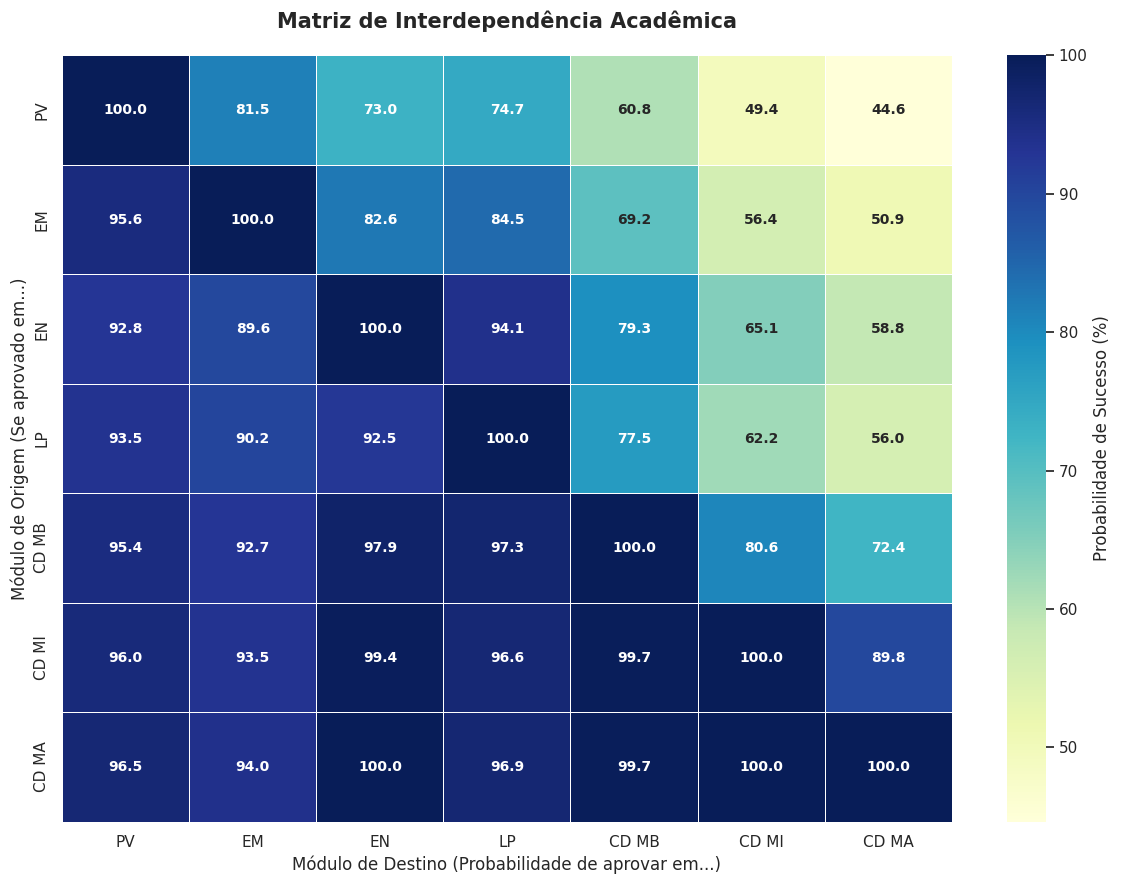

In [ ]:
exibir_fase1_matriz_interdependencia(df_final)

#Matriz de Interdependência

Esta matriz de calor (Heatmap) quantifica a correlação de sucesso entre os módulos, respondendo a uma pergunta estratégica: Dado que um aluno foi aprovado no módulo X, qual a probabilidade de ele obter êxito no módulo Y?

#Observações Principais:

* Gradiente de Retenção:

Observamos que a probabilidade de um aluno aprovado em Projeto de Vida (PV) concluir o módulo técnico avançado (CD MA) é de $44,6\%$. Esse índice reflete o período de adaptação e o funil de seleção natural que ocorre no início do curso.

* Aumento da Probabilidade por Proximidade:

Existe uma correlação positiva entre a proximidade dos módulos e a taxa de sucesso. Módulos vizinhos apresentam índices muito elevados, como a transição de CD MI para CD MA ($89,8\%$).



/tmp/ipykernel_747/1492621061.py:100: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_747/1492621061.py:102: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



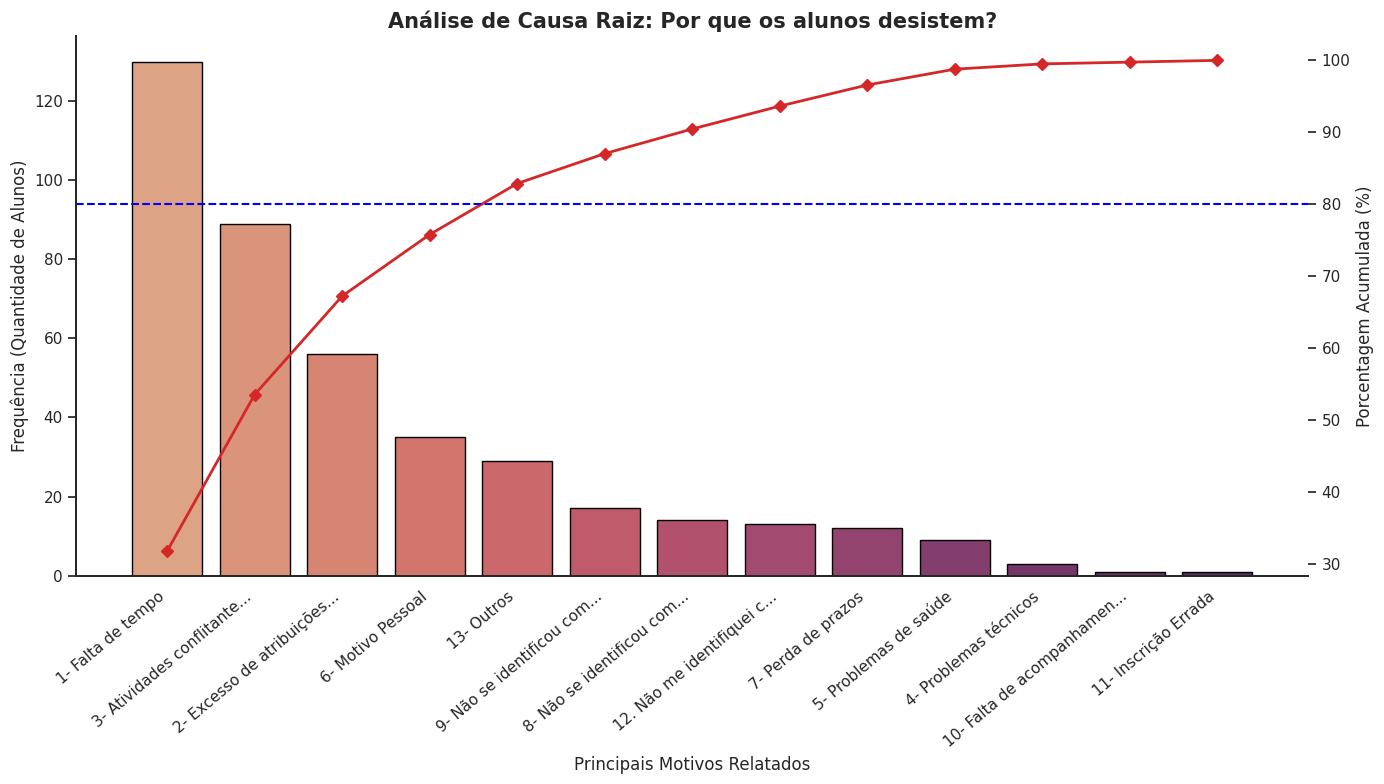

In [ ]:
exibir_fase1_causa_raiz_pareto(df_final)

#Análise de Causa Raiz: Diagrama de Pareto

O Diagrama de Pareto é uma ferramenta estratégica que nos permite identificar a hierarquia das causas de desistência, separando os "poucos vitais" dos "muitos triviais". Esta visualização é fundamental para direcionar planos de ação com maior eficiência.

#Observações Principais:

* A Regra de Pareto (80/20):

A linha de corte estabelecida em $80\%$ (linha tracejada azul) delimita os motivos que, somados, representam a vasta maioria das desistências. A subida mais expressiva da curva vermelha indica quais categorias possuem maior peso estatístico no volume total de evasão.

* Foco Estratégico:

A análise sugere que, ao concentrarmos esforços e políticas de retenção especificamente nos motivos situados à esquerda do gráfico (antes do corte de $80\%$), conseguiremos mitigar a evasão de forma drástica, atacando as dores que impactam a maior parcela do corpo discente.

* Priorização de Intervenção:

Em vez de dispersar recursos em todos os problemas relatados, o gráfico nos orienta a focar nas causas de alta alavancagem. Resolver os problemas concentrados no início da curva pode reduzir o índice geral de desistência em até $80\%$, otimizando os recursos pedagógicos e de suporte do programa.

---------------------------------------------

# Fase 2: Detalhamento do Perfil e Cruzamento de Dados

A segunda fase aprofunda a análise demográfica, segmentando os alunos por localização (Interior x Capital), nível de escolaridade (Ensino Médio, Egresso ou Ensino Superior) e gênero. O intuito é verificar, por exemplo, se houve disparidade de performance entre homens e mulheres ou se determinadas variáveis sociodemográficas influenciaram diretamente nas taxas de aprovação em todas as disciplinas.

In [ ]:
def exibir_fase2_top10_cidades_evasao(df):
    """Top 10 Cidades com maior volume de evasão + Taxa de Impacto"""
    evadidos = df[df['SITUACAO_FINAL'] == 'Desistente']['CIDADE'].value_counts().nlargest(10)
    total_evadidos_geral = len(df[df['SITUACAO_FINAL'] == 'Desistente'])

    plt.figure(figsize=(12, 7))
    ax = sns.barplot(x=evadidos.values, y=evadidos.index, hue=evadidos.index, palette='Reds_r', edgecolor='black', alpha=0.8)

    for i, v in enumerate(evadidos.values):
        cidade = evadidos.index[i]
        total_cid = len(df[df['CIDADE'] == cidade])
        taxa_local = (v / total_cid * 100) if total_cid > 0 else 0
        ax.text(v + 1, i, f'n={int(v)} ({taxa_local:.1f}% local)', va='center', fontweight='bold', color='#a50f15')

    plt.title('Top 10 Cidades: Foco Crítico de Evasão\n(Volume Absoluto e % de Impacto Local)', pad=25, fontweight='bold')
    plt.xlabel('Volume de Desistentes'); plt.ylabel('Cidades do Ceará')
    plt.grid(axis='x', linestyle='--', alpha=0.3); sns.despine()
    plt.tight_layout(); plt.show()

def exibir_fase2_genero_sucesso(df):
    """Perfil de Gênero: Sucesso vs Evasão (Versão Slim)"""
    t = pd.crosstab(df['SEXO'], df['SITUACAO_FINAL'])
    t = t[[c for c in ['Desistente', 'Concluinte'] if c in t.columns]]

    ax = t.plot(kind='bar', color=['#d62728', '#2ca02c'], figsize=(12, 6), width=0.7, edgecolor='black', alpha=0.85, rot=0)

    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            total = t.iloc[int(round(p.get_x() + p.get_width()/2))].sum()
            perc = (h / total * 100) if total > 0 else 0
            ax.annotate(f'n={int(h)}\n({perc:.1f}%)', (p.get_x() + p.get_width()/2, h),
                        ha='center', va='bottom', weight='bold', size=10, xytext=(0, 5), textcoords='offset points')

    plt.title('Perfil de Gênero: Sucesso vs. Evasão', pad=20, weight='bold')
    plt.ylabel('Quantidade de Alunos'); plt.ylim(0, t.values.max() * 1.3)
    sns.despine(); plt.tight_layout(); plt.show()

def exibir_fase2_matriz_resiliencia_heatmap(df):
    """Matriz de Resiliência: Sucesso Integral (8/8) por Idade e Geografia"""
    cols = [f'Status {d}' for d in ['PV', 'EM', 'LP', 'EN', 'CD MB', 'CD MI', 'CD MA', 'Imersão']]
    termos = ['Aprovado', 'Ciclo II', 'Média 5', 'Concluído']

    df['SUCESSO_8_8'] = df[cols].apply(lambda x: all(any(t in str(val) for t in termos) for val in x), axis=1)
    df['GEO'] = df['RMF OU INTERIOR'].str.upper().apply(lambda x: 'INTERIOR' if 'INTERIOR' in str(x) else 'CAPITAL/RMF')
    df['FX_ETARIA'] = pd.cut(df['IDADE_INSCRICAO'], bins=[0, 18, 25, 35, 45, 100], labels=['Sub-18', '18-25', '26-35', '36-45', '45+'])

    matriz = df.pivot_table(index='FX_ETARIA', columns='GEO', values='SUCESSO_8_8', aggfunc='mean', observed=True) * 100

    plt.figure(figsize=(10, 7))
    sns.heatmap(matriz.fillna(0), annot=True, fmt=".1f", cmap="YlGnBu", linewidths=2, linecolor='white',
                cbar_kws={'label': 'Taxa de Sucesso Integral (%)'}, annot_kws={"size": 12, "weight": "bold"})

    plt.title('Matriz de Resiliência: Sucesso Integral (8/8)\nComparativo Geracional e Geográfico', pad=25, fontweight='bold')
    plt.xlabel('Localização'); plt.ylabel('Faixa Etária'); plt.tight_layout(); plt.show()

def exibir_fase2_distribuicao_etaria_hist(df):
    """Distribuição Etária com Média e Mediana"""
    plt.figure(figsize=(12, 6))
    sns.histplot(df['IDADE_INSCRICAO'], kde=True, color='#1f77b4', bins=25, alpha=0.6, edgecolor='white')

    med, avg = df['IDADE_INSCRICAO'].median(), df['IDADE_INSCRICAO'].mean()
    plt.axvline(med, color='#d62728', linestyle='--', label=f'Mediana: {med:.1f}')
    plt.axvline(avg, color='#2ca02c', linestyle=':', label=f'Média: {avg:.1f}')

    plt.title('Distribuição Etária: Perfil dos Inscritos', pad=20, fontweight='bold')
    plt.xlabel('Idade'); plt.ylabel('Frequência'); plt.legend(); sns.despine(); plt.show()

import matplotlib.patheffects as path_effects

def exibir_fase2_escolaridade_genero_stack(df):
    """Escolaridade por Gênero: Totais detalhados no Sumário Inferior"""
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    df_adj = df.copy()
    # Padronização para legibilidade
    df_adj['SEXO'] = df_adj['SEXO'].map({'F': 'Feminino', 'M': 'Masculino'}).fillna(df_adj['SEXO'])

    # Criando a tabela de cruzamento (Frequência)
    t = pd.crosstab(df_adj['SEXO'], df_adj['ESCOLARIDADE'])

    # Plotagem limpa
    ax = t.plot(kind='bar', stacked=True, figsize=(14, 9), colormap='viridis',
                edgecolor='black', alpha=0.8, width=0.6)

    # Adicionando o Valor Total Geral no topo de cada barra
    for i, total in enumerate(t.sum(axis=1)):
        ax.text(i, total + 2, f'Total: {int(total)}', ha='center',
                va='bottom', fontweight='bold', fontsize=12)

    # Personalizando o Sumário (Legenda) com os números por gênero
    novas_legendas = []
    for escolaridade in t.columns:
        # Extrai os valores para cada gênero
        masc = t.loc['Masculino', escolaridade] if 'Masculino' in t.index else 0
        fem = t.loc['Feminino', escolaridade] if 'Feminino' in t.index else 0
        # Formata o texto que aparecerá na legenda
        texto = f"{escolaridade} (M: {int(masc)} | F: {int(fem)})"
        novas_legendas.append(texto)

    # Configuração de Eixos e Títulos
    plt.title('Perfil Acadêmico: Escolaridade por Gênero', pad=35, fontweight='bold', fontsize=16)
    plt.ylabel('Quantidade de Estudantes', fontsize=12)
    plt.xlabel('Gênero', fontsize=12)
    plt.xticks(rotation=0)

    # Linhas de grade para auxiliar a leitura no eixo Y
    plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

    # Aplicando a nova legenda detalhada abaixo do gráfico
    plt.legend(labels=novas_legendas,
               title='Níveis de Escolaridade (M: Masculino | F: Feminino)',
               bbox_to_anchor=(0.5, -0.15),
               loc='upper center',
               ncol=1, # Coluna única para garantir que os textos longos fiquem legíveis
               frameon=True,
               facecolor='white',
               edgecolor='gray',
               fontsize=10)

    sns.despine()
    plt.tight_layout()
    plt.show()

def exibir_fase2_boxplot_idade_situacao(df):
    """Variabilidade Etária: Concluinte vs Desistente"""
    plt.figure(figsize=(10, 7))
    sns.boxplot(x='SITUACAO_FINAL', y='IDADE_INSCRICAO', data=df, hue='SITUACAO_FINAL',
                palette={'Concluinte': '#2ca02c', 'Desistente': '#d62728'}, width=0.4, showmeans=True,
                meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})

    avg_g = df['IDADE_INSCRICAO'].mean()
    plt.axhline(avg_g, color='gray', linestyle='--', alpha=0.5, label=f'Média Geral: {avg_g:.1f}')

    plt.title('Variabilidade Etária por Desempenho Final\n(Concluintes vs. Desistentes)', pad=25, fontweight='bold')
    plt.ylabel('Idade'); plt.legend(loc='upper right'); sns.despine(); plt.show()

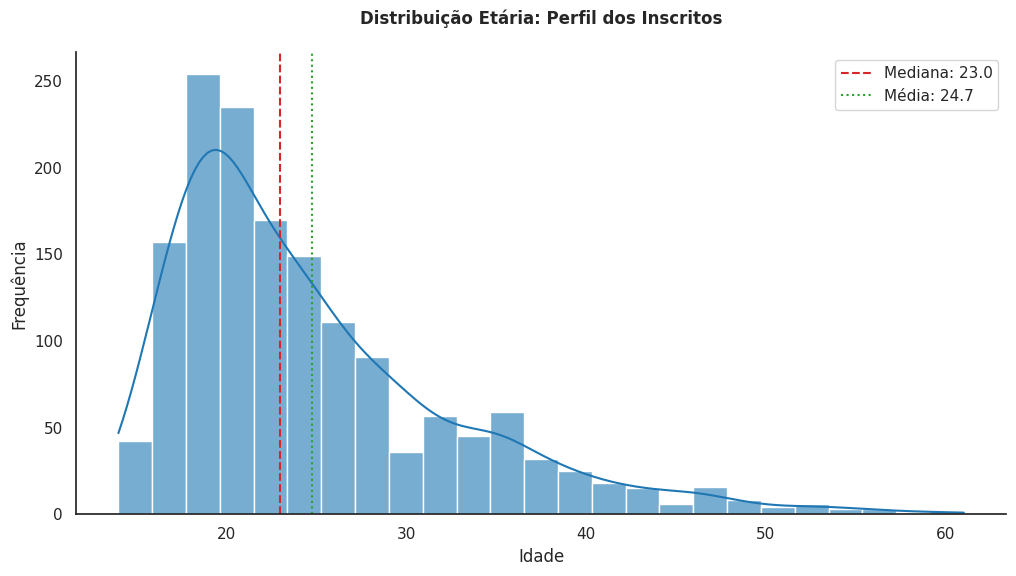

In [ ]:
exibir_fase2_distribuicao_etaria_hist(df_final)

#Perfil Demográfico: Distribuição Etária dos Inscritos

O histograma de distribuição etária revela a composição geracional do programa, permitindo identificar o perfil predominante e a presença de grupos geracionais distintos no itinerário do curso.

#Observações Principais:

* Concentração Juvenil:

Observa-se que a maior frequência de inscritos se concentra na faixa dos 20 anos. A Mediana ($23$ anos) e a Média ($24,7$ anos) confirmam que o programa atinge majoritariamente o público jovem, em fase de inserção no mercado de trabalho ou transição de carreira.

* Tendência de Assimetria:

A proximidade entre média e mediana indica uma distribuição relativamente coesa, embora apresente uma cauda à direita composta por alunos de faixas etárias mais elevadas.

* Diversidade Geracional:

Apesar do foco evidente na juventude, a presença de outliers entre os 50 e 60 anos demonstra que o programa também atrai profissionais com maior tempo de estrada, interessados na requalificação tecnológica.

* Público-Alvo:

Em suma, a grande parcela dos alunos está situada no início da vida adulta, o que valida a proposta do programa em fomentar competências digitais para as novas gerações.

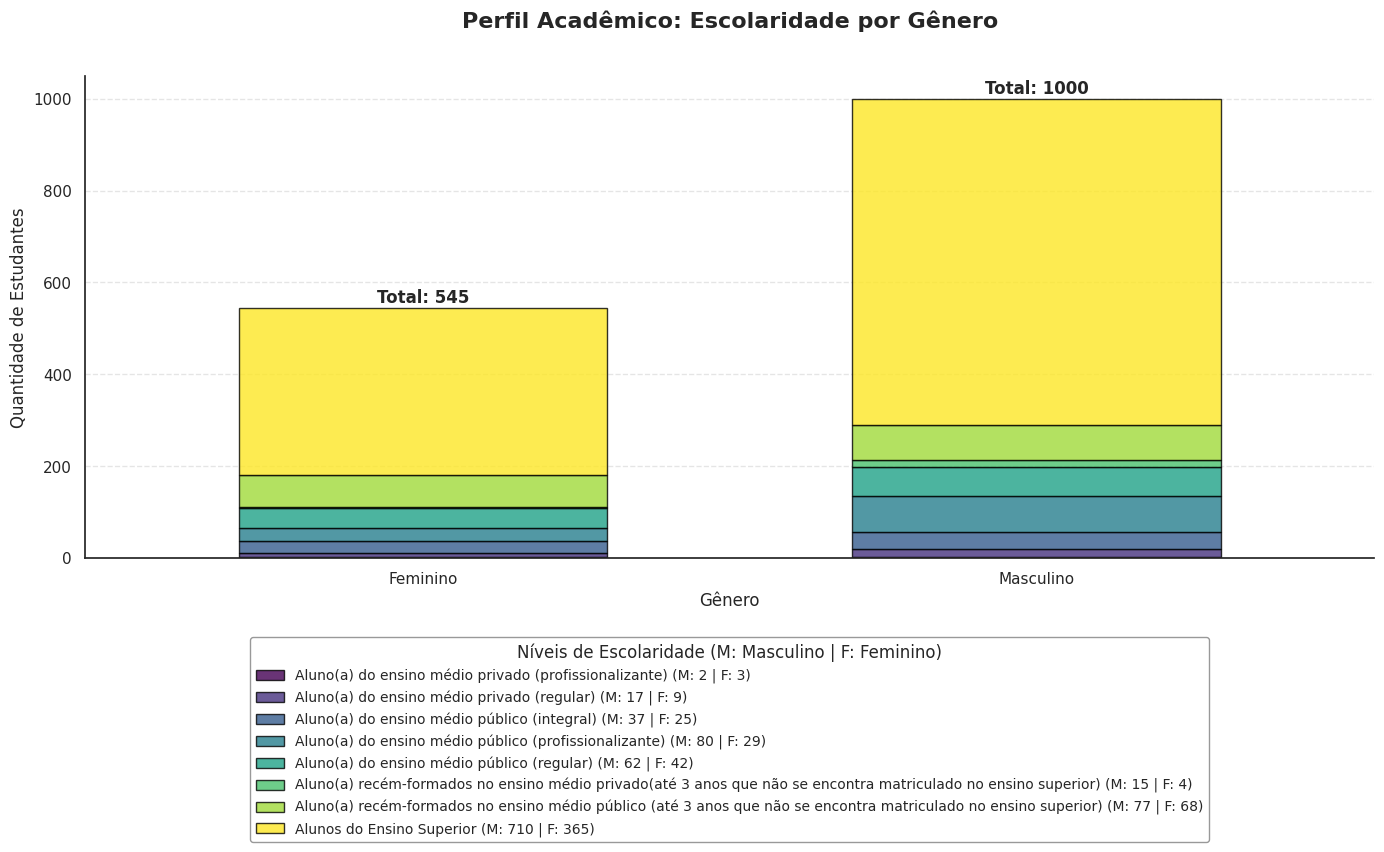

In [ ]:
exibir_fase2_escolaridade_genero_stack(df_final)

#Interseção entre Escolaridade e Gênero

Esta visualização estratifica o corpo discente através do cruzamento entre o nível de instrução e a identidade de gênero, permitindo mapear o capital cultural dos ingressantes no programa.

#Observações Principais:

* Paridade de Qualificação:

Observa-se uma distribuição de escolaridade notavelmente equilibrada entre os gêneros. O perfil acadêmico das alunas do gênero feminino apresenta simetria com o dos alunos do gênero masculino, indicando que o programa atrai perfis qualificados independentemente do sexo.

* Predomínio do Nível Superior:

A grande maioria dos inscritos, em ambos os gêneros, são alunos do Ensino Superior. Este dado sugere que o programa atua como um hub de especialização e transição de carreira para indivíduos que já possuem uma base acadêmica.

* Acessibilidade e Inclusão:

Embora o Nível Superior seja predominante, a presença de outros níveis de escolaridade mostra que o programa mantém portas abertas para diferentes trajetórias, ainda que o maior engajamento ocorra no segmento universitário.

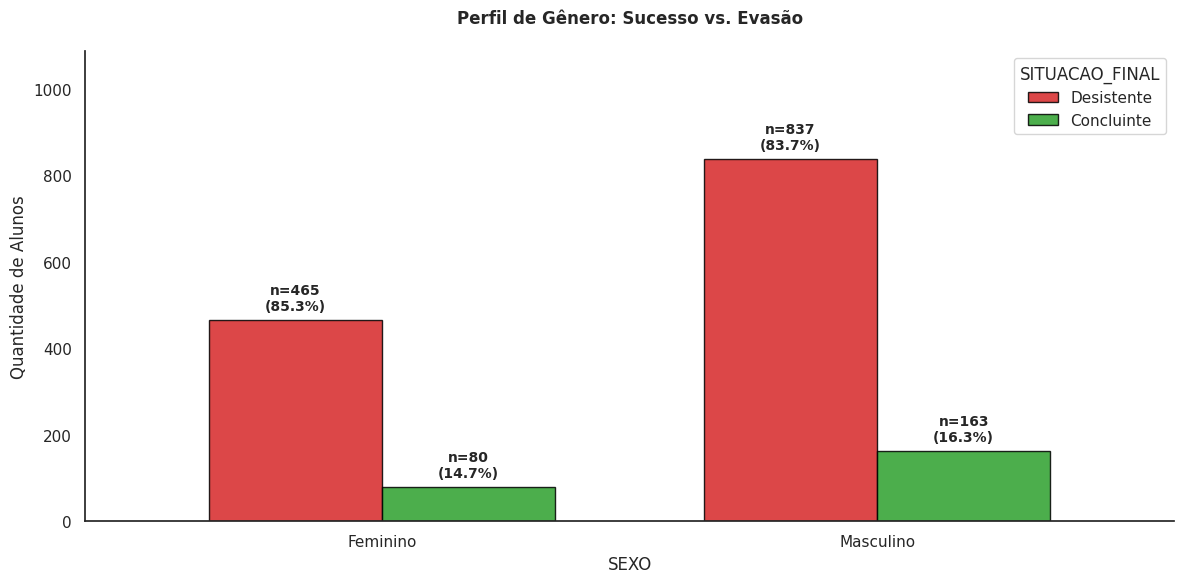

In [ ]:
exibir_fase2_genero_sucesso(df_final)

#Análise de Desempenho e Equidade de Gênero

Este gráfico estratifica o sucesso acadêmico (Concluintes vs. Desistentes) sob a perspectiva de gênero, permitindo avaliar se a identidade de gênero atua como uma variável de impacto na retenção dos estudantes.

#Observações Principais:

* Representatividade Quantitativa:

Observa-se que o grupo de alunos do gênero masculino detém a maior parcela do volume total de inscritos. O grupo feminino representa, em termos absolutos, uma proporção significativamente menor (aproximadamente metade do contingente masculino).

* Paridade de Resultados:

Apesar da disparidade no volume de ingressantes, as taxas percentuais de aprovação e evasão não apresentam variações estatisticamente drásticas. As proporções de sucesso são notavelmente próximas entre os dois grupos.

* Independência de Gênero no Sucesso:

A similaridade nos índices de conclusão sugere que o sucesso no itinerário do curso independe da identidade de gênero do discente. Uma vez ingressos no curso, tanto homens quanto mulheres apresentam níveis de resiliência e aproveitamento acadêmico próximos.

* Conclusão Estratégica:

Embora o programa atraia majoritariamente o público masculino, os dados validam a eficácia da metodologia para ambos os gêneros, reforçando que a capacidade técnica e o engajamento são distribuídos de forma equilibrada no corpo discente.

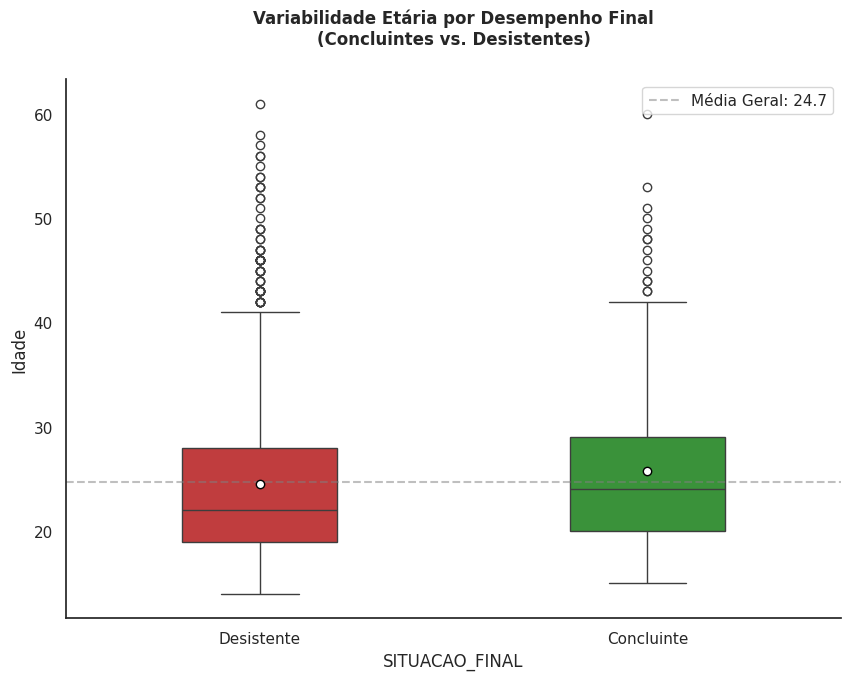

In [ ]:
exibir_fase2_boxplot_idade_situacao(df_final)

#Análise de Variabilidade Etária e Desempenho Final (Boxplot)

O diagrama de caixa (Boxplot) permite comparar a distribuição de idades entre os grupos de Concluintes e Desistentes, revelando nuances sobre a maturidade acadêmica e a persistência no curso.

#Observações Principais:

* Perfil de Maturidade:

Embora ambos os grupos possuam o "coração" da sua distribuição (o corpo da caixa) concentrado entre os $20$ e $30$ anos, observa-se que a caixa verde (Concluintes) está posicionada em um patamar levemente superior à caixa vermelha (Desistentes). Isso indica que o perfil de sucesso no programa tende a uma idade ligeiramente mais avançada, sugerindo que a maturidade pode ser um fator de resiliência.

* O (Ponto Branco):

O círculo branco no interior das caixas representa a Média Aritmética de cada grupo.

1. O ponto branco dos Concluintes está posicionado acima da linha tracejada (Média Geral), confirmando que o grupo de sucesso é, em média, mais velho que a base total.

2. O ponto branco dos Desistentes situa-se abaixo da média geral, reforçando que a evasão atinge com maior intensidade os alunos mais jovens.


* Outliers (Valores Atípicos):

Os pontos isolados acima das hastes representam os alunos fora da curva comum. Nota-se um volume maior de outliers no grupo de desistentes, o que sugere que, embora o programa atraia pessoas de todas as idades, o desafio de retenção em faixas etárias muito avançadas (acima dos $40$ anos) ainda é um ponto de atenção.

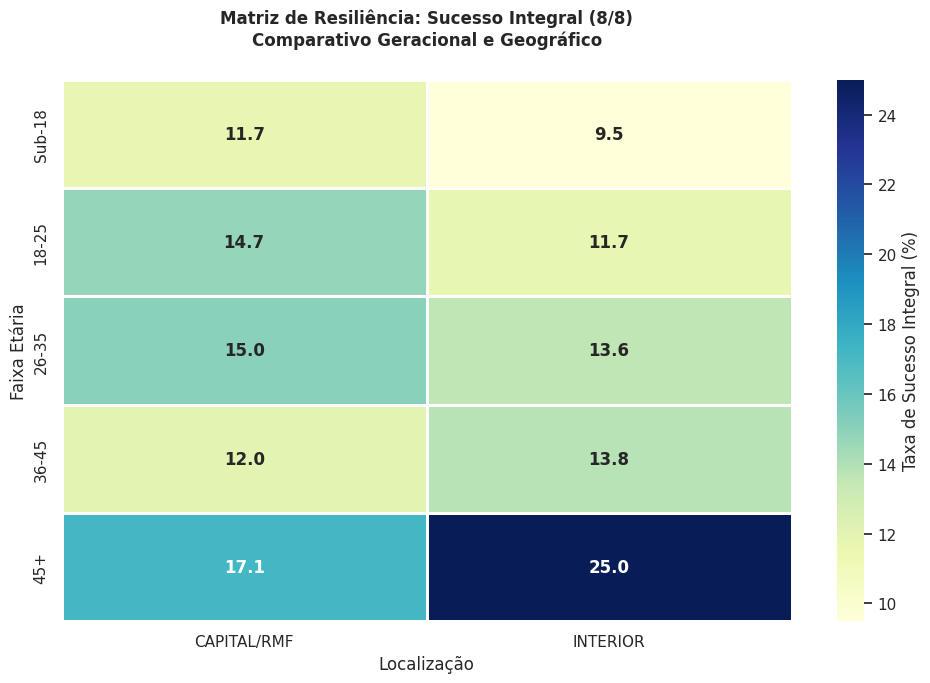

In [ ]:
exibir_fase2_matriz_resiliencia_heatmap(df_final)

#Matriz de Resiliência: Sucesso Integral por Geografia e Faixa Etária

Esta matriz de calor (Heatmap) apresenta a taxa de Sucesso Integral — ou seja, alunos que obtiveram aprovação em todos os módulos do curso — cruzando a localização geográfica com o perfil geracional.

#Observações Principais:

* Inversão de Resiliência Juvenil:

Observa-se um padrão claro nas faixas etárias mais jovens (até $35$ anos). Nestes segmentos, os alunos da Capital/RMF apresentam taxas de sucesso integral ligeiramente superiores aos alunos do Interior. Isso pode estar associado a uma maior facilidade de acesso à infraestrutura tecnológica ou conectividade nos grandes centros urbanos.

* O Protagonismo do Interior (36+):

O cenário se inverte drasticamente nas faixas etárias acima de $36$ anos. Os alunos do Interior nestas categorias superam a performance dos seus pares da Capital/RMF. Este dado sugere que o público mais maduro do interior possui um nível de comprometimento e resiliência superior, possivelmente vendo no programa uma oportunidade crítica de requalificação profissional em suas regiões.

* Maturidade:

A matriz confirma que a maturidade (idade avançada) atua como um fator compensatório para as barreiras geográficas. Enquanto o jovem do interior enfrenta maiores desafios de retenção, o adulto do interior se consolida como um dos perfis mais resilientes de todo o itinerário formativo.

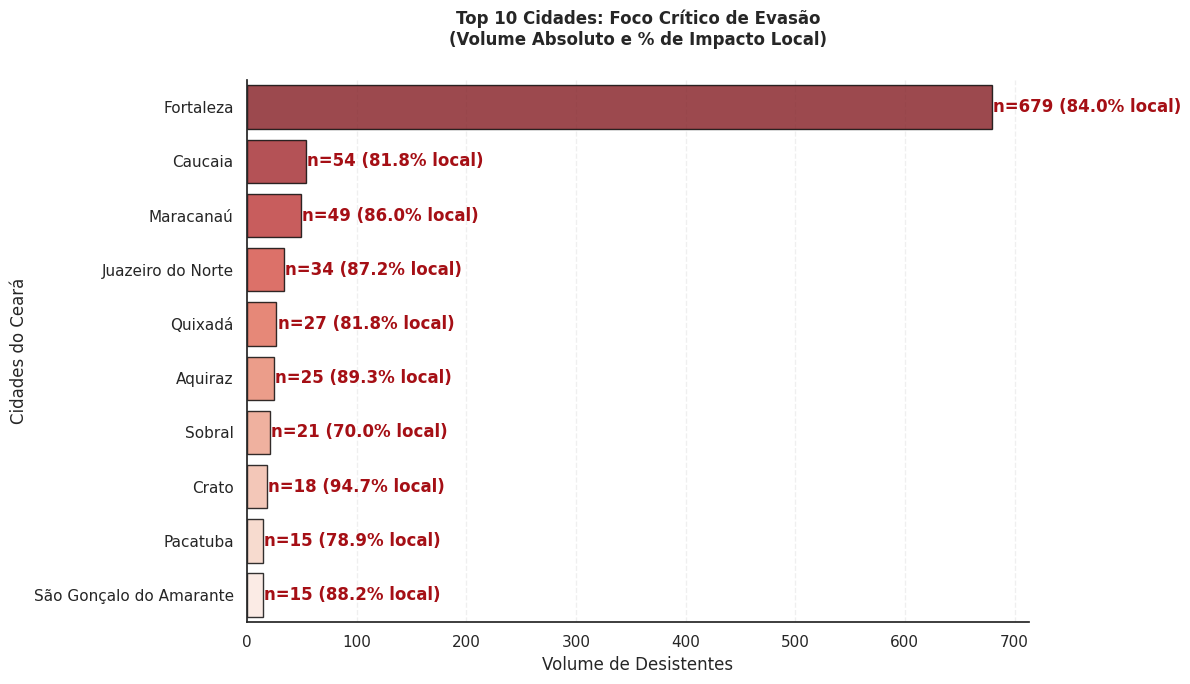

In [ ]:
exibir_fase2_top10_cidades_evasao(df_final)

#Top 10 Cidades: Foco de Evasão (Volume & Proporção)

Esta análise identifica as dez cidades com os maiores índices de desistência, permitindo separar o impacto do volume populacional do impacto real da taxa de evasão local.

#Observações Principais:

* O Efeito Capital (Volume):

Fortaleza destaca-se isoladamente no volume absoluto de evadidos. Contudo, este dado deve ser interpretado com cautela, pois a capital detém a maior base de alunos inscritos, o que naturalmente eleva os números brutos de desistência.

* Gravidade Local (Proporção):

Ao analisarmos a Taxa de Impacto Local ($n$ evadidos / $N$ inscritos na cidade), o cenário muda. Embora Fortaleza tenha o maior volume, cidades como Crato apresentam uma severidade relativa superior.

* Comparativo Crítico:

Nota-se que o Crato possui uma proporção de evasão aproximadamente $10\%$ superior à de Fortaleza. Isso indica que, embora o número de alunos no Crato seja menor, a dificuldade de retenção naquela localidade é proporcionalmente mais aguda, sugerindo barreiras regionais específicas (como conectividade ou logística) que superam a média da capital.


In [ ]:
def relatorio_performance_geografica(df):
    """Relatório Geográfico Compacto com Auditoria de Integridade"""
    c = pd.crosstab(df['CIDADE'], df['SITUACAO_FINAL'])
    for col in ['Desistente', 'Concluinte']:
        if col not in c.columns: c[col] = 0

    c['Total'] = c.sum(axis=1)
    c['Evasao_%'], c['Sucesso_%'] = (c['Desistente']/c['Total']*100), (c['Concluinte']/c['Total']*100)

    # Exibição da Tabela (Top 145)
    print("="*60 + "\nPERFORMANCE GEOGRÁFICA (ORDEM: DESISTÊNCIA)\n" + "="*60)
    display(c.sort_values('Desistente', ascending=False)[['Total', 'Desistente', 'Concluinte', 'Evasao_%', 'Sucesso_%']].head(145))

    n_base, n_desist, n_concl = len(df), c['Desistente'].sum(), c['Concluinte'].sum()
    ev_geral = (n_desist / n_base * 100) if n_base > 0 else 0

    print(f"\n{'='*20} RESUMO EXECUTIVO {'='*20}")
    print(f"Total Analisado: {n_base} | Concluintes: {n_concl} | Evasão Geral: {ev_geral:.2f}%")
    print(f"Cidade Crítica:  {c['Desistente'].idxmax()} ({c['Desistente'].max()} desistentes)")

    print(f"\n{'!'*20} AUDITORIA {'!'*20}")
    print(f"{'✅' if n_base == c['Total'].sum() else '❌'} INTEGR. BASE: {n_base} vs {c['Total'].sum()}")
    print(f"{'✅' if (n_desist + n_concl) == n_base else '❌'} COESÃO SITUAÇÃO: {n_desist + n_concl} vs {n_base}")
    print("="*60)

relatorio_performance_geografica(df_final)

PERFORMANCE GEOGRÁFICA (ORDEM: DESISTÊNCIA)


SITUACAO_FINAL,Total,Desistente,Concluinte,Evasao_%,Sucesso_%
CIDADE,,,,,
Fortaleza,808,679,129,84.03,15.97
Caucaia,66,54,12,81.82,18.18
Maracanaú,57,49,8,85.96,14.04
Juazeiro do Norte,39,34,5,87.18,12.82
Quixadá,33,27,6,81.82,18.18
...,...,...,...,...,...
Forquilha,1,0,1,0.00,100.00
Pacoti,1,0,1,0.00,100.00
Mulungu,1,0,1,0.00,100.00



==================== RESUMO EXECUTIVO ====================
Total Analisado: 1545 | Concluintes: 243 | Evasão Geral: 84.27%
Cidade Crítica:  Fortaleza (679 desistentes)

!!!!!!!!!!!!!!!!!!!! AUDITORIA !!!!!!!!!!!!!!!!!!!!
✅ INTEGR. BASE: 1545 vs 1545
✅ COESÃO SITUAÇÃO: 1545 vs 1545


---------------------------------------------

In [ ]:
def robo_auditor_final(df):
    print("="*75)
    print("     AUDITORIA: VEREDITO FINAL DE COESÃO")
    print("="*75)

    erros = 0
    alertas = 0
    termos_sucesso = ['Aprovado', 'Ciclo II', 'Média 5', 'Concluído']

    # 1. VALIDAÇÃO DE VOLUME (O "N" TOTAL)
    total_atual = len(df)
    n_esperado = 1545
    if total_atual == n_esperado:
        print(f"✅ BASE: Volume de {total_atual} registros confirmado.")
    else:
        print(f"⚠️ AVISO: O DF possui {total_atual} linhas (Esperado: {n_esperado}).")
        alertas += 1

    # 2. (APROVADOS vs EVADIDOS)
    concluintes = len(df[df['SITUACAO_FINAL'] == 'Concluinte'])
    desistentes = len(df[df['SITUACAO_FINAL'] == 'Desistente'])
    taxa_evasao = (desistentes / total_atual) * 100 if total_atual > 0 else 0

    print(f"\n--- BALANÇO DE DESFECHOS ---")
    print(f"✅ CONCLUINTES (SUCESSO): {concluintes}")
    print(f"❌ EVADIDOS (DESISTENTES): {desistentes}")
    print(f"📊 TAXA DE EVASÃO REAL:    {taxa_evasao:.2f}%")

    if (concluintes + desistentes) == total_atual:
        print("✅ INTEGRIDADE: A soma de Aprovados + Evadidos fecha 100% da base.")
    else:
        print(f"❌ RUÍDO: {total_atual - (concluintes + desistentes)} alunos sem situação definida!")
        erros += 1

    # 3. CONSISTÊNCIA DE JORNADA (8/8)
    status_cols = [f'Status {d}' for d in ['PV', 'EM', 'LP', 'EN', 'CD MB', 'CD MI', 'CD MA', 'Imersão']]
    cols_presentes = [c for c in status_cols if c in df.columns]

    if len(cols_presentes) == len(status_cols):
        df_concluintes = df[df['SITUACAO_FINAL'] == 'Concluinte']
        def check_sucesso_completo(row):
            return all(any(t in str(row[c]) for t in termos_sucesso) for c in status_cols)

        pendencias = df_concluintes[~df_concluintes.apply(check_sucesso_completo, axis=1)]

        if len(pendencias) == 0:
            print(f"\n✅ QUALIDADE: Todos os {concluintes} concluintes venceram os 8 desafios.")
        else:
            print(f"\n⚠️ ATENÇÃO: {len(pendencias)} concluintes possuem pendência em módulos anteriores.")
            #print("   (Justificativa: Entradas tardias ou aproveitamento de créditos).")
            alertas += 1

    # 4. GEOGRÁFICA E GÊNERO
    genero_check = df['SEXO'].astype(str).str.strip().str.upper().str[0]
    n_fem = (genero_check == 'F').sum()
    n_masc = (genero_check == 'M').sum()

    print(f"\n--- PERFIL DEMOGRÁFICO ---")
    if (n_fem + n_masc) == total_atual:
        print(f"✅ GÊNERO: Todos os {total_atual} alunos validados ({n_fem} F / {n_masc} M).")
    else:
        print(f"⚠️ AVISO: {total_atual - (n_fem + n_masc)} registros com gênero não identificado.")
        alertas += 1

    # 5. TRATAMENTO DE IDADE
    nulos_idade = df['IDADE_INSCRICAO'].isna().sum()
    if nulos_idade == 0:
        print("✅ IDADE: Nenhuma idade nula detectada.")
    else:
        print(f"❌ ERRO: Existem {nulos_idade} idades vazias na base.")
        erros += 1

    print("\n" + "="*75)
    if erros == 0 and alertas == 0:
        print("      🌟 RESULTADO: DADOS IMPECÁVEIS PARA APRESENTAÇÃO 🌟")
    elif erros == 0:
        print(f"      ✅ RESULTADO: COESO, MAS COM {alertas} ALERTAS DE ATENÇÃO")
    else:
        print(f"      🚨 RESULTADO: {erros} ERROS CRÍTICOS ENCONTRADOS")
    print("="*75)

robo_auditor_final(df_final)

     AUDITORIA: VEREDITO FINAL DE COESÃO
✅ BASE: Volume de 1545 registros confirmado.

--- BALANÇO DE DESFECHOS ---
✅ CONCLUINTES (SUCESSO): 243
❌ EVADIDOS (DESISTENTES): 1302
📊 TAXA DE EVASÃO REAL:    84.27%
✅ INTEGRIDADE: A soma de Aprovados + Evadidos fecha 100% da base.

⚠️ ATENÇÃO: 36 concluintes possuem pendência em módulos anteriores.

--- PERFIL DEMOGRÁFICO ---
✅ GÊNERO: Todos os 1545 alunos validados (545 F / 1000 M).
✅ IDADE: Nenhuma idade nula detectada.

      ✅ RESULTADO: COESO, MAS COM 1 ALERTAS DE ATENÇÃO


# REFERÊNCIAS PARA LIMPEZA DE DADOOS

Sobre o preenchimento de valores ausentes:
- Nas tabelas que contem dados numericos é recomendado deixar o dado ausente sem substituilo ou imputar nada.

-[Working with missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html)

-[Nullable integer data type](https://pandas.pydata.org/docs/user_guide/integer_na.html)


"A substituição indiscriminada de valores ausentes por zero ou outros valores arbitrários distorce as medidas de tendência central e variabilidade, comprometendo a integridade estatística da análise. A prática recomendada é manter os dados como nulos (NaN/NA) ou utilizar métodos de imputação fundamentados, para que as funções estatísticas ignorem corretamente a ausência de informação sem enviesar os resultados."

Referência: Little, R. J. A., & Rubin, D. B. (2019). Statistical Analysis with Missing Data (3rd ed.). Wiley.

[Link para consulta](https://www.wiley.com/en-us/Statistical+Analysis+with+Missing+Data%2C+3rd+Edition-p-9780470526798)